# Phase 1: Time and Financial Volume Analysis

**Author:** Vijay

This notebook analyzes yearly transaction activity and financial volume across Medici Bank branches and transaction types.

## 1. Load the Transaction Dataset

Import the required libraries and load `medici_transactions.csv` into a pandas DataFrame.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../medici_transactions.csv"

df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 80,230
Columns: 13


,branch,counterparty,credit_account,credit_account_2,credit_amount,credit_amount_2,currency,date,debit_account,debit_amount,description,id,type
0,Florence,Republic of Florence,Cash,NaN,82833.66,NaN,florin,1390-01-01,Loans Receivable - Government,82833.66,Emergency war financing for Florence defense,1,war_financing
1,Florence,Republic of Florence,Cash,NaN,124432.65,NaN,florin,1390-01-01,Loans Receivable - Government,124432.65,Loan to Venice for Lombardy Wars operations,2,war_financing
2,Bruges,Gold Merchant,Cash,NaN,42534.83,NaN,florin,1390-01-01,Loans Receivable,42534.83,Loan issued to Gold Merchant from Bruges branch,3,loan_issuance
3,Florence,Republic of Florence,Cash,NaN,1617678.46,NaN,florin,1390-01-01,Loans Receivable - Government,1617678.46,War financing for Florentine operations agains...,4,war_financing
4,Florence,Republic of Florence,Cash,NaN,27742.84,NaN,florin,1390-01-01,Loans Receivable - Government,27742.84,Loan to Venice for Lombardy Wars operations,5,war_financing


Convert Dates and Extract the Year

Convert the `date` column to a datetime type and extract the year for time-based analysis.

In [23]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

print(df["date"].dtype)
df[["date", "year"]].head()

datetime64[us]


,date,year
0,1390-01-01,1390
1,1390-01-01,1390
2,1390-01-01,1390
3,1390-01-01,1390
4,1390-01-01,1390


## 3. Transactions by Year and Time Trends

Count transactions by year and visualize changes in banking activity between 1390 and 1440.

In [24]:
transactions_by_year = (
    df.groupby("year")
      .size()
      .rename("transaction_count")
      .reset_index()
)

transactions_by_year

,year,transaction_count
0,1390,1632
1,1391,1520
2,1392,1614
3,1393,1519
4,1394,1565
5,1395,1606
6,1396,1554
7,1397,1547
8,1398,1602
9,1399,1571


## 4. Total Financial Volume

Calculate the total and average transaction values using the `debit_amount` column.

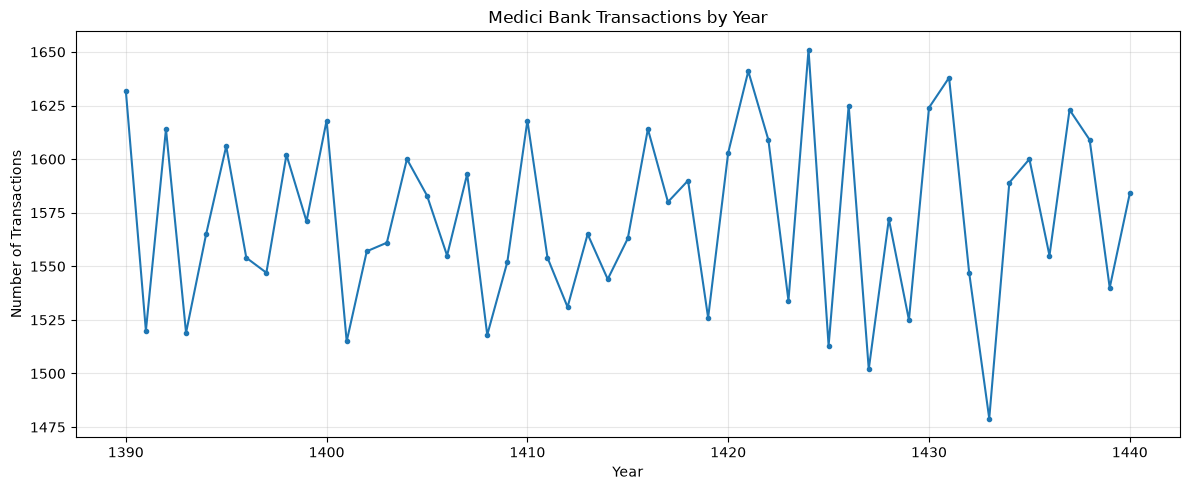

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    transactions_by_year["year"],
    transactions_by_year["transaction_count"],
    marker="o",
    markersize=3
)

plt.title("Medici Bank Transactions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
highest_activity_year = transactions_by_year.loc[
    transactions_by_year["transaction_count"].idxmax()
]

lowest_activity_year = transactions_by_year.loc[
    transactions_by_year["transaction_count"].idxmin()
]

print(
    f"Highest activity: {int(highest_activity_year['year'])} "
    f"with {int(highest_activity_year['transaction_count']):,} transactions"
)

print(
    f"Lowest activity: {int(lowest_activity_year['year'])} "
    f"with {int(lowest_activity_year['transaction_count']):,} transactions"
)

Highest activity: 1424 with 1,651 transactions
Lowest activity: 1433 with 1,479 transactions


In [27]:
df["debit_amount"] = pd.to_numeric(df["debit_amount"], errors="coerce")

total_volume = df["debit_amount"].sum()
average_volume = df["debit_amount"].mean()

print(f"Total financial volume: {total_volume:,.2f} florins")
print(f"Average transaction value: {average_volume:,.2f} florins")

Total financial volume: 21,612,302,640.94 florins
Average transaction value: 269,379.32 florins


In [28]:
invalid_amounts = df["debit_amount"].isna().sum()
print(f"Invalid or missing debit amounts: {invalid_amounts:,}")

Invalid or missing debit amounts: 0


## 5. Financial Volume by Branch

Compare the total financial volume processed by each Medici Bank branch.

In [29]:
volume_by_branch = (
    df.groupby("branch", as_index=False)["debit_amount"]
      .sum()
      .rename(columns={"debit_amount": "total_volume"})
      .sort_values("total_volume", ascending=False)
)

volume_by_branch["percentage_of_total"] = (
    volume_by_branch["total_volume"] / total_volume * 100
)

volume_by_branch

,branch,total_volume,percentage_of_total
3,Florence,1.268937e+10,58.713660
7,Rome,5.933693e+09,27.455164
8,Venice,5.524101e+08,2.555998
1,Bruges,5.089550e+08,2.354932
0,Avignon,5.069876e+08,2.345829
4,Geneva,4.815355e+08,2.228062
6,Milan,4.705859e+08,2.177398
5,London,4.687265e+08,2.168795
2,Constance,3.500000e+04,0.000162


In [30]:
branch_display = volume_by_branch.copy()

branch_display["total_volume"] = branch_display["total_volume"].map(
    lambda value: f"{value:,.2f}"
)

branch_display["percentage_of_total"] = branch_display[
    "percentage_of_total"
].map(lambda value: f"{value:.2f}%")

branch_display

,branch,total_volume,percentage_of_total
3,Florence,"12,689,373,996.45",58.71%
7,Rome,"5,933,693,096.46",27.46%
8,Venice,"552,410,062.21",2.56%
1,Bruges,"508,955,001.35",2.35%
0,Avignon,"506,987,638.74",2.35%
4,Geneva,"481,535,499.29",2.23%
6,Milan,"470,585,850.98",2.18%
5,London,"468,726,495.46",2.17%
2,Constance,"35,000.00",0.00%


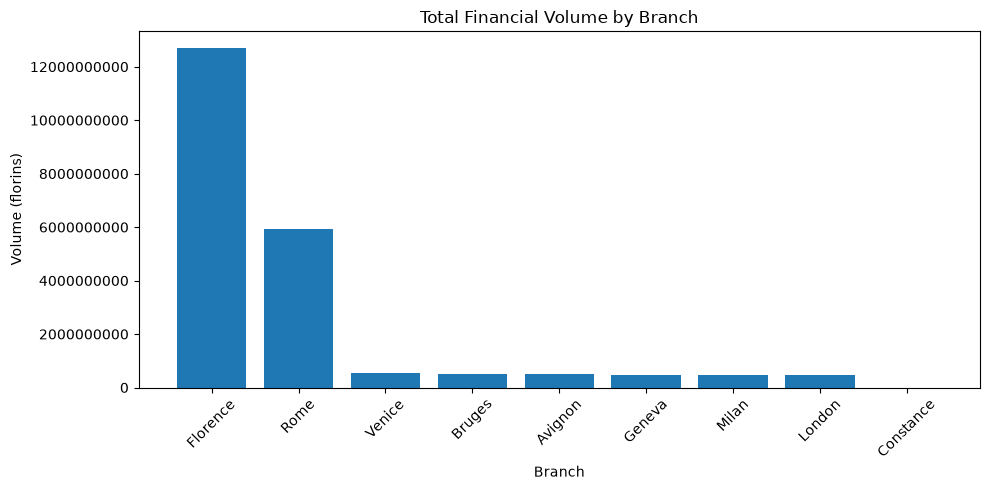

In [31]:
plt.figure(figsize=(10, 5))

plt.bar(
    volume_by_branch["branch"],
    volume_by_branch["total_volume"]
)

plt.title("Total Financial Volume by Branch")
plt.xlabel("Branch")
plt.ylabel("Volume (florins)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

## 6. Financial Volume by Transaction Type

Compare transaction categories by total volume, transaction count, and average value.

In [32]:
volume_by_type = (
    df.groupby("type", as_index=False)["debit_amount"]
      .sum()
      .rename(columns={"debit_amount": "total_volume"})
      .sort_values("total_volume", ascending=False)
)

volume_by_type["percentage_of_total"] = (
    volume_by_type["total_volume"] / total_volume * 100
)

volume_by_type

,type,total_volume,percentage_of_total
7,war_financing,1.210777e+10,56.022593
2,deposit,5.924146e+09,27.410988
3,loan_issuance,1.575495e+09,7.289805
1,bill_of_exchange,7.324064e+08,3.388840
4,loan_repayment,5.472854e+08,2.532287
8,withdrawal,5.296369e+08,2.450627
0,alum_trade,1.546544e+08,0.715585
5,operating_expense,4.087193e+07,0.189114
6,ransom_payment,3.500000e+04,0.000162


In [33]:
type_display = volume_by_type.copy()

type_display["total_volume"] = type_display["total_volume"].map(
    lambda value: f"{value:,.2f}"
)

type_display["percentage_of_total"] = type_display[
    "percentage_of_total"
].map(lambda value: f"{value:.2f}%")

type_display

,type,total_volume,percentage_of_total
7,war_financing,"12,107,772,332.19",56.02%
2,deposit,"5,924,145,611.16",27.41%
3,loan_issuance,"1,575,494,610.58",7.29%
1,bill_of_exchange,"732,406,422.35",3.39%
4,loan_repayment,"547,285,446.82",2.53%
8,withdrawal,"529,636,920.24",2.45%
0,alum_trade,"154,654,365.05",0.72%
5,operating_expense,"40,871,932.55",0.19%
6,ransom_payment,"35,000.00",0.00%


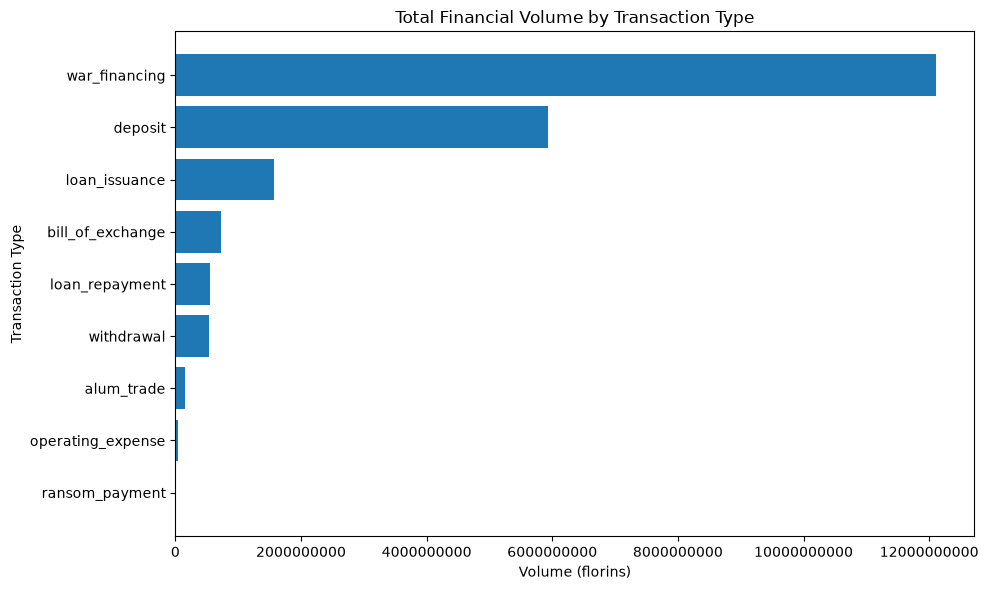

In [34]:
plt.figure(figsize=(10, 6))

plt.barh(
    volume_by_type["type"],
    volume_by_type["total_volume"]
)

plt.title("Total Financial Volume by Transaction Type")
plt.xlabel("Volume (florins)")
plt.ylabel("Transaction Type")
plt.ticklabel_format(style="plain", axis="x")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Branch × Transaction-Type Summary

Examine which transaction categories contribute to the financial volume of each branch.

In [35]:
type_summary = (
    df.groupby("type")
      .agg(
          transaction_count=("type", "size"),
          total_volume=("debit_amount", "sum"),
          average_value=("debit_amount", "mean")
      )
      .sort_values("total_volume", ascending=False)
)

type_summary

,transaction_count,total_volume,average_value
type,,,
war_financing,10568,1.210777e+10,1.145701e+06
deposit,25031,5.924146e+09,2.366724e+05
loan_issuance,7478,1.575495e+09,2.106840e+05
bill_of_exchange,6428,7.324064e+08,1.139400e+05
loan_repayment,8170,5.472854e+08,6.698720e+04
withdrawal,6374,5.296369e+08,8.309334e+04
alum_trade,5193,1.546544e+08,2.978131e+04
operating_expense,10987,4.087193e+07,3.720027e+03
ransom_payment,1,3.500000e+04,3.500000e+04


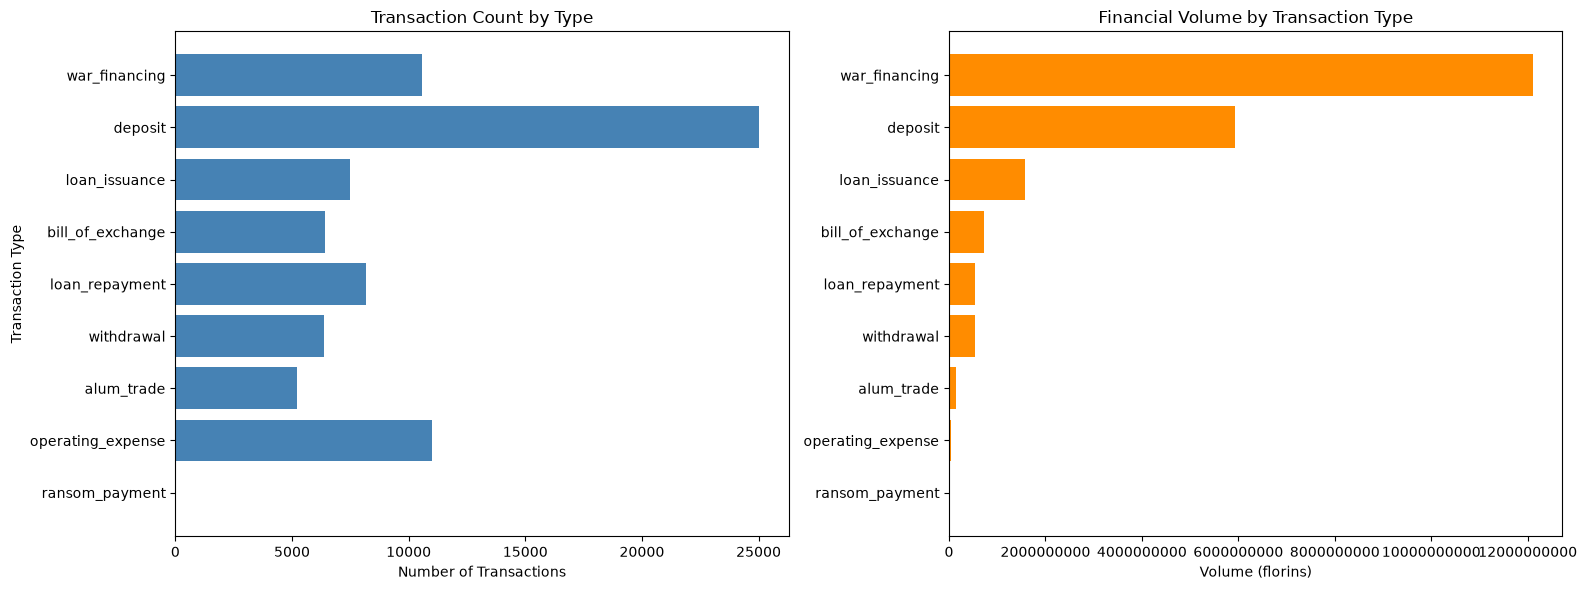

In [36]:
type_chart_data = type_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Transaction count chart
axes[0].barh(
    type_chart_data["type"],
    type_chart_data["transaction_count"],
    color="steelblue"
)
axes[0].set_title("Transaction Count by Type")
axes[0].set_xlabel("Number of Transactions")
axes[0].set_ylabel("Transaction Type")
axes[0].invert_yaxis()

# Total volume chart
axes[1].barh(
    type_chart_data["type"],
    type_chart_data["total_volume"],
    color="darkorange"
)
axes[1].set_title("Financial Volume by Transaction Type")
axes[1].set_xlabel("Volume (florins)")
axes[1].set_ylabel("")
axes[1].ticklabel_format(style="plain", axis="x")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Key Findings and Observations

Summarize the most important results from the time and financial-volume analysis.

In [37]:
branch_type_summary = pd.pivot_table(
    df,
    index="branch",
    columns="type",
    values="debit_amount",
    aggfunc="sum",
    fill_value=0
)

branch_type_summary

type,alum_trade,bill_of_exchange,deposit,loan_issuance,loan_repayment,operating_expense,ransom_payment,war_financing,withdrawal
branch,,,,,,,,,
Avignon,0.00,8.893440e+07,7.049841e+07,1.991768e+08,7.244281e+07,5300482.27,0.0,0.000000e+00,70634713.79
Bruges,0.00,8.774283e+07,7.439378e+07,1.931275e+08,7.753455e+07,5558014.37,0.0,0.000000e+00,70598335.24
Constance,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,35000.0,0.000000e+00,0.00
Florence,55148209.61,1.050327e+08,7.014012e+07,2.065400e+08,7.501422e+07,5261332.76,0.0,1.210777e+10,64465109.96
Geneva,0.00,9.547641e+07,6.142746e+07,1.925394e+08,6.425023e+07,5176832.41,0.0,0.000000e+00,62665146.90
London,0.00,9.373037e+07,6.829431e+07,1.754385e+08,6.318853e+07,4980223.97,0.0,0.000000e+00,63094590.39
Milan,0.00,8.455007e+07,6.739083e+07,1.777170e+08,6.607137e+07,4752346.19,0.0,0.000000e+00,70104220.36
Rome,46859956.43,9.105455e+07,5.442471e+09,2.165955e+08,6.453721e+07,4584441.84,0.0,0.000000e+00,67590198.81
Venice,52646199.01,8.588512e+07,6.952944e+07,2.143599e+08,6.424653e+07,5258258.74,0.0,0.000000e+00,60484604.79


In [38]:
branch_type_summary["Total"] = branch_type_summary.sum(axis=1)

branch_type_summary = branch_type_summary.sort_values(
    "Total",
    ascending=False
)

branch_type_summary

type,alum_trade,bill_of_exchange,deposit,loan_issuance,loan_repayment,operating_expense,ransom_payment,war_financing,withdrawal,Total
branch,,,,,,,,,,
Florence,55148209.61,1.050327e+08,7.014012e+07,2.065400e+08,7.501422e+07,5261332.76,0.0,1.210777e+10,64465109.96,1.268937e+10
Rome,46859956.43,9.105455e+07,5.442471e+09,2.165955e+08,6.453721e+07,4584441.84,0.0,0.000000e+00,67590198.81,5.933693e+09
Venice,52646199.01,8.588512e+07,6.952944e+07,2.143599e+08,6.424653e+07,5258258.74,0.0,0.000000e+00,60484604.79,5.524101e+08
Bruges,0.00,8.774283e+07,7.439378e+07,1.931275e+08,7.753455e+07,5558014.37,0.0,0.000000e+00,70598335.24,5.089550e+08
Avignon,0.00,8.893440e+07,7.049841e+07,1.991768e+08,7.244281e+07,5300482.27,0.0,0.000000e+00,70634713.79,5.069876e+08
Geneva,0.00,9.547641e+07,6.142746e+07,1.925394e+08,6.425023e+07,5176832.41,0.0,0.000000e+00,62665146.90,4.815355e+08
Milan,0.00,8.455007e+07,6.739083e+07,1.777170e+08,6.607137e+07,4752346.19,0.0,0.000000e+00,70104220.36,4.705859e+08
London,0.00,9.373037e+07,6.829431e+07,1.754385e+08,6.318853e+07,4980223.97,0.0,0.000000e+00,63094590.39,4.687265e+08
Constance,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,35000.0,0.000000e+00,0.00,3.500000e+04


In [39]:
branch_type_display = branch_type_summary.map(
    lambda value: f"{value:,.2f}"
)

branch_type_display

type,alum_trade,bill_of_exchange,deposit,loan_issuance,loan_repayment,operating_expense,ransom_payment,war_financing,withdrawal,Total
branch,,,,,,,,,,
Florence,"55,148,209.61","105,032,687.07","70,140,119.40","206,539,986.12","75,014,219.34","5,261,332.76",0.00,"12,107,772,332.19","64,465,109.96","12,689,373,996.45"
Rome,"46,859,956.43","91,054,548.25","5,442,471,256.87","216,595,479.85","64,537,214.41","4,584,441.84",0.00,0.00,"67,590,198.81","5,933,693,096.46"
Venice,"52,646,199.01","85,885,117.22","69,529,444.06","214,359,911.72","64,246,526.67","5,258,258.74",0.00,0.00,"60,484,604.79","552,410,062.21"
Bruges,0.00,"87,742,830.96","74,393,783.10","193,127,488.60","77,534,549.08","5,558,014.37",0.00,0.00,"70,598,335.24","508,955,001.35"
Avignon,0.00,"88,934,397.06","70,498,405.36","199,176,834.05","72,442,806.21","5,300,482.27",0.00,0.00,"70,634,713.79","506,987,638.74"
Geneva,0.00,"95,476,408.60","61,427,463.08","192,539,419.50","64,250,228.80","5,176,832.41",0.00,0.00,"62,665,146.90","481,535,499.29"
Milan,0.00,"84,550,065.82","67,390,829.03","177,717,017.07","66,071,372.51","4,752,346.19",0.00,0.00,"70,104,220.36","470,585,850.98"
London,0.00,"93,730,367.37","68,294,310.26","175,438,473.67","63,188,529.80","4,980,223.97",0.00,0.00,"63,094,590.39","468,726,495.46"
Constance,0.00,0.00,0.00,0.00,0.00,0.00,"35,000.00",0.00,0.00,"35,000.00"


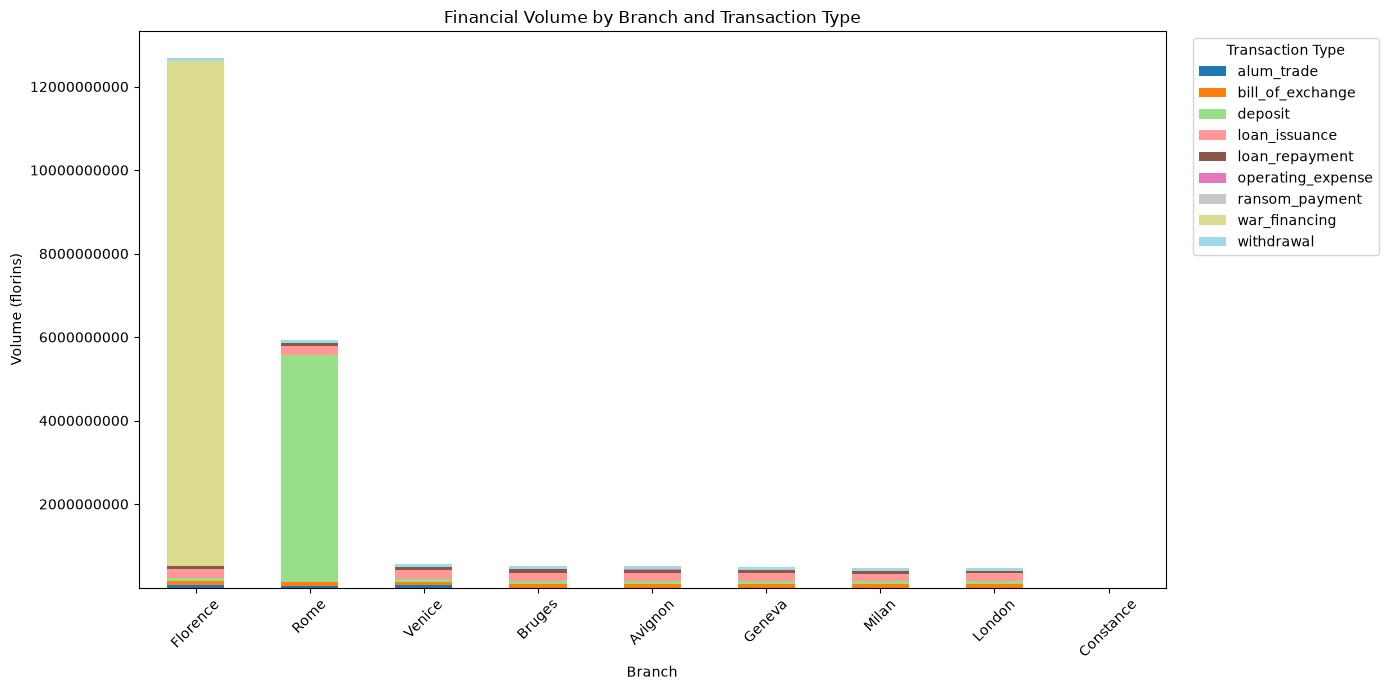

In [40]:
branch_type_chart = branch_type_summary.drop(columns="Total")

branch_type_chart.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    colormap="tab20"
)

plt.title("Financial Volume by Branch and Transaction Type")
plt.xlabel("Branch")
plt.ylabel("Volume (florins)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.legend(
    title="Transaction Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [41]:
highest_year = transactions_by_year.loc[
    transactions_by_year["transaction_count"].idxmax()
]

lowest_year = transactions_by_year.loc[
    transactions_by_year["transaction_count"].idxmin()
]

print(
    f"The highest-activity year was {int(highest_year['year'])}, "
    f"with {int(highest_year['transaction_count']):,} transactions."
)

print(
    f"The lowest-activity year was {int(lowest_year['year'])}, "
    f"with {int(lowest_year['transaction_count']):,} transactions."
)

The highest-activity year was 1424, with 1,651 transactions.
The lowest-activity year was 1433, with 1,479 transactions.
